# <!-- TITLE --> Unsupervised classification of sound units segmented from soundscapes
---
<!-- DESC --> Machine learning framework to perform unsupervised classification of sound units segmented from soundscapes
<!-- AUTHOR --> : Sylvain Haupert and Juan Ulloa

### Objectives :
 - Providing a script to analyze soundscapes on a GoogleDrive
 - Testing a method to rapidly screen the acoustic content in soundscapes

The goal is to provide a workflow to process soundscapes coming from different recorders set in a tropical rain forest for 24h.

### What we're going to do :

*   Installing Bambird
*   Running Bambird on a dataset
*   Checking the clusters and compare them with a library of sounds produced by expected animals.

### Dataset :

The dataset is a collection of audio recordings from the project XPRIZE (Singapore). Each audio recording lasts 30 min, and they were recorded all day long during the entire May 2022

In this script, you will use the package bambird (more specificaly some functions from bamscape that contains the functions to analyse soundscapes).


# Step 1 - Setup the environment
---

Get the information about the virtual machine that Google gave you

In [1]:
# get info about the virtual machine
!lscpu |grep 'Model name'
!lscpu |grep 'Core(s) per socket:'
!free -h --si | awk  '/Mem:/{print $2}'

Model name:                           13th Gen Intel(R) Core(TM) i7-13700H
Core(s) per socket:                   14
63G


## 1.1 Global settings

Change or adapt the settings :
- to import the required packages
- to set the directories and the paths
- to set some global constatns
- to set the parameters for bambird

### 1.1.1 Import packages

In [2]:
# Load basic packages
# --------------------
import shutil
import numpy as np
from pathlib import Path
import os
import datetime
import yaml
import sys
from glob import glob
from tqdm import tqdm

# scikit-learn (machine learning) package
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

from scipy.signal.windows import tukey

# notebook display
from IPython.display import clear_output # to clear output of jupyter cell

# pandas
import pandas as pd

# import the custom packages
#----------------------------
import maad
import bambird

# Parallel processing packages
from concurrent import futures



Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


### 1.1.2 Define the constants

**WARNING** Adapt the paths to your local configuration

In [3]:
# Define constants
# ----------------

# directory where to store the data 
# !!! NEED TO BE ADAPTED TO YOU OWN CONFIG !!!
# PROJECT_PATH    = Path('/media/haupert/data/mes_projets/05_xprize/final')
PROJECT_PATH    = Path('/media/haupert/LaCie/mes_projets_data/erika_ecuador/results')

# !!! NEED TO BE ADAPTED TO YOU OWN CONFIG !!!
# ARCHIVE_PATH    = Path('/media/haupert/LaCie/mes_projets_data/xprize/french_guiana_july_ground')
# ARCHIVE_PATH    = Path('/media/haupert/LaCie/mes_projets_data/xprize/canopy_station')
# ARCHIVE_PATH    = Path('/media/haupert/LaCie/mes_projets_data/xprize/Mock-Dataset/active/canopy_dome_10b_32khz')
# ARCHIVE_PATH   = Path('/media/haupert/data/mes_projets_data/Mock-Dataset/passive/audiomoth_passive_1_384_kHz')
# ARCHIVE_PATH    = Path('/media/haupert/LaCie/mes_projets_data/xprize/Finals-Data/rec1dmu')
# ARCHIVE_PATH    = Path('/media/haupert/LaCie/mes_projets_data/xprize/Finals-Data/rec3dmu')
# ARCHIVE_PATH    = Path('/media/haupert/LaCie/mes_projets_data/xprize/Finals-Data/rec4dmu')
# ARCHIVE_PATH    = Path('/media/haupert/LaCie/mes_projets_data/xprize/Finals-Data/rec4dmu_v2')
# ARCHIVE_PATH    = Path('/media/haupert/LaCie/mes_projets_data/xprize/Finals-Data/rec6dmu')
# ARCHIVE_PATH    = Path('/media/haupert/LaCie/mes_projets_data/xprize/Finals-Data/rec7dmu')

# ARCHIVE_PATH    = Path('/media/haupert/data/mes_projets_data/nROI/dataset/_00_optional_dataset/dB@petchora/audio/')
# ARCHIVE_PATH    = Path('/home/haupert/Downloads/')
ARCHIVE_PATH    = Path('/media/haupert/LaCie/mes_projets_data/erika_ecuador/Enregistrements_Morpho_projet/')

# !!! NEED TO BE ADAPTED TO YOU OWN CONFIG !!!
PACKAGE_PATH = Path('../')

DATA_PATH = PROJECT_PATH / Path('DATASETS_BIRDNET')
SAVE_PATH = PROJECT_PATH / Path('RESULTS_BIRDNET')

# subdirectories where to store the dataset and the extracted rois
DATASET_NAME    = ARCHIVE_PATH.stem + '_all'
ROIS_NAME       = Path(str(DATASET_NAME) +'_ROIS')

# subsample the dataframe containing all the audio recordings
EVERY_N_ROWS = 1 # Set to 1 to keep all files.

# audio file extension
AUDIO_EXTENSION = 'wav' #<=========================================================== CHANGE TO WAV or wav

# Select the configuration file to segment, compute features and get the clusters
# test if the variable ARCHIVE_PATH contains the string '384_kHz'
if '384_kHz' in str(ARCHIVE_PATH):
    CONFIG_FILE     = 'config_soundscape_birdnet_bats.yaml'    
else:
    CONFIG_FILE     = 'config_soundscape_birdnet.yaml'

EXTRACT_FEATURES = True

# Load the configuration file
# -----------------------------
params = bambird.load_config(PACKAGE_PATH / "src/bambird" / CONFIG_FILE)

# select the ROIs with SNR higher than SNR_HLIM
SNR_HLIM = 16           #@param {type:"slider", min:0, max:90, step:1}

# select the ROIs with centroid frequency between CENTROID_FREQ_LLIM and CENTROID_FREQ_HLIM (in Hz)
CENTROID_FREQ_HLIM = 20000 
CENTROID_FREQ_LLIM = 0

# number of files per cluster (decrease that number to reduce the amount of data to download
NUM_SAMPLES_BY_CLUSTER = 50


use the function <bambird.extract_rois_in_soundscape> to segment ROIS


## 1.2 Define some local functions

In [4]:
# %%
def date_from_filename (filename) :
    # filename with format 'XXXX_yyyymmdd_hhmmss.wav'
    # extract year, month, day, hour, minute and second from the filename
    # notice the underscore _ which splits the filename into several parts
    year = int(filename.split('_')[1][0:4])
    month = int(filename.split('_')[1][4:6])
    day = int(filename.split('_')[1][6:8])
    hour = int(filename.split('_')[2][0:2])
    minute = int(filename.split('_')[2][2:4])
    #second = int(filename.split('_')[2][4:6])
    second = 00

    # create a datetime object from the extracted parameters
    date = datetime.datetime(year, month, day, hour, minute, second)

    return date

def diffcumspec(spec1, spec2):
    
    s1 = spec1[:, 1] if spec1.ndim == 2 and spec1.shape[1] == 2 else spec1
    s2 = spec2[:, 1] if spec2.ndim == 2 and spec2.shape[1] == 2 else spec2
    
    n1 = len(s1)
    n2 = len(s2)
    
    if n1 != n2:
        raise ValueError("spec1 and spec2 must have the same length")
    
    if np.isnan(s1).any() or np.isnan(s2).any():
        D = np.nan
        print("The data set contains 'NA' values. The returned values have been set to NA.")
        return D
    else:
        if np.any(s1 < 0) or np.any(s2 < 0):
            raise ValueError("spectra (spec1 and/or spec2) do not have to be in dB")
        
        if np.sum(s1) == 0:
            print("Caution!, spec1 is a null spectrum")
        
        if np.sum(s2) == 0:
            print("Caution!, spec2 is a null spectrum")
        
        s1 = s1 / np.sum(s1)
        s2 = s2 / np.sum(s2)
        
        cum_s1 = np.cumsum(s1)
        cum_s2 = np.cumsum(s2)
        
        D = np.sum(np.abs(cum_s1 - cum_s2)) / n1

    return D

# %%
def find_representative_samples (df_cluster):
            
    # copy
    df = df_cluster.copy()

    # set cluster_number as the index
    # df.set_index("cluster_number", inplace = True)

    # convert the features to numpy array
    df['features'] = df['features'].apply(lambda x: np.array(x))
    
    # dataframe with the average features of each cluster
    df_avg = pd.DataFrame({'features' : df.groupby('cluster_number')['features'].apply(np.mean)})
    
    # dataframe with the nearest samples to the center of each cluster
    df['dist_likeness'] = np.nan
    df['normdist'] = np.nan
    df['dist'] = np.nan
    df['cosine_likeness'] = np.nan
    df['cosine'] = np.nan
    df['model'] = 0
    
    for index, y in df_avg.iterrows():  

        # if noise, continue
        if index == -1 :
            continue
        
        # variables
        y = y.features  # average features
        X = np.array(df[df.cluster_number == index].features.tolist()) # all the features of the cluster

        # distance
        neighbors = NearestNeighbors(n_neighbors=len(X))
        neighbors_fit = neighbors.fit(X)
        distances, index_sample = neighbors_fit.kneighbors([y])       
        d = distances[0]

        # angle
        a = cosine_similarity(X, y.reshape(1,-1)).flatten()
        
        # Give an indicator of the likeness of the sample regarding its cluster
        #-------------------------------------------------------------------------
        # 1 is the closest sample to the model (the most likeness of the cluster)
        # 0.5 is as half the distance between the furthest and the closest
        # 0 is the furthest sample (should be very different to the avg sample)
        df.update(pd.DataFrame({'dist_likeness': 1-(d-min(d))/(max(d)-min(d))},
                                index =  df[df.cluster_number == index].iloc[index_sample[0]].index ))
        # normalized distance
        # 1 is the closest to the model 
        # 2 is twice the distance to the model
        # 10 is ten times the minimum distance to the model
        df.update(pd.DataFrame({'normdist': d/d[0]},
                                index =  df[df.cluster_number == index].iloc[index_sample[0]].index ))
        # absolute distance
        d = distances[0]
        df.update(pd.DataFrame({'dist': d},
                                index =  df[df.cluster_number == index].iloc[index_sample[0]].index ))
        # similarity (cosine)
        # 1 both vectors are colinear (the angle is 0°)
        # 0 both vectors are orthogonal (the angle is 90°)
        df.update(pd.DataFrame({'cosine': a},
                                index =  df[df.cluster_number == index].iloc[index_sample[0]].index ))
        # 1 is the closest sample to the model (the most likeness of the cluster)
        # 0.5 is as half the angle between the furthest and the closest
        # 0 is the furthest sample (should be very different to the avg sample)
        df.update(pd.DataFrame({'cosine_likeness': (a-min(a))/(max(a)-min(a))},
                                index =  df[df.cluster_number == index].iloc[index_sample[0]].index ))

        # df_cluster_per_file['features'] = df_cluster_per_file['features'].apply(lambda x: np.array(x))
        # # Compute the silhouette scores for each sample
        # X = np.array(df_cluster_per_file.features.tolist())
        # silhouette = silhouette_samples(X, df_cluster_per_file['cluster_number'])
        # df_cluster_per_file['silhouette'] = silhouette

        # add a column "model"
        # 1 => the closest to the average features = model, 0 either.        
        idx = df[df.cluster_number == index].iloc[index_sample[0][0]].name
        df.at[idx,'model'] = 1

    return df

# %%
def select_cluster_percentile (
                            df_cluster,
                            column      = "cluster_number",
                            percentile  = 75,
                            remove_noise= True
                            ) :
    # Count the number of ROIs per cluster and select the first "percentile" of
    # cluster, from the biggest (percentile = 1) to the smallest (percentile = 99)
    # Does not take into account the cluster "noise" (=-1)

    # copy the dataframe
    df = df_cluster.copy()

    # clean df_cluster by removing the noise : -1
    if remove_noise :
        df = df[df[column] >-1]

    # count the number of each value
    counts = df[column].value_counts()

    # sort counts value from the highest count to the lowest
    counts = counts.sort_values(ascending=False)

    # select the vector of id
    cumulative = counts.cumsum() / counts.sum()
    mask = cumulative > (percentile / 100)
    idx = cumulative[mask].index[0]
    selected = counts.loc[:idx]

    # filter the dataframe to keep only the biggest clusters
    df = df[df[column].isin(selected.index)]

    return df

def copy_matching_files(source_dir, 
                        destination_dir, 
                        pattern="*"):
    """
    Copies files matching a pattern from source directory to destination directory.

    Args:
        source_dir: Path to the source directory.
        destination_dir: Path to the destination directory.
        pattern: Glob pattern to match files (default: "*").
    """
    from glob import glob
    
    source_dir = Path(source_dir)
    destination_dir = Path(destination_dir)

    # Get all matching files as Path objects
    matching_files = glob(str(source_dir / pattern), recursive=True)
    matching_files = [Path(file) for file in matching_files]

    # Create destination directory if it doesn't exist
    if not destination_dir.exists():
        destination_dir.mkdir()

    # Copy each matching file
    for file in matching_files:
        relative_path = file.relative_to(source_dir)
        dest_file = destination_dir / relative_path
        dest_file.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(file, dest_file)

def extract_roi (filename, min_t, max_t, min_f, max_f, margins=None, normalize=False, save_path=None):
    """
    create a function that open an audio file and extract a roi
    
    Parameters
    ----------
    filename : str
        path to the audio file
    min_t : float
        start time of the roi in seconds
    max_t : float
        end time of the roi in seconds
    min_f : float
        start frequency of the roi in Hz
    max_f : float
        end frequency of the roi in Hz
    margins : list  (default None)
        margins to add to the roi (time, frequency) in seconds and Hz
    save_path : str (default None)
        path to save the roi
    """
    
    # open the audio file
    s, fs = maad.sound.load(filename)

    # duration
    duration = len(s) / fs

    if margins is not None :
        min_t = max(0.0, min_t - margins[0])
        max_t = min(duration, max_t + margins[0])
        min_f = max(1, min_f - margins[1])
        max_f = min(fs/2, max_f + margins[1])

    # extract the roi
    roi = maad.sound.trim(s, fs, min_t, max_t)
    roi = maad.sound.select_bandwidth(roi, fs, fcut=[min_f, max_f], forder=1, ftype='bandpass')
    # fade in and fade out roi
    # create a tukey window of 1% of the roi duration
    win = tukey(roi.size, alpha=0.01)
    roi = roi * win

    # normalization
    if normalize:
        roi = maad.sound.normalize(roi)
    
    # save the roi
    if save_path is not None:
        # test if the parent directory exists
        if not os.path.exists(os.path.dirname(save_path)):
            os.makedirs(os.path.dirname(save_path))
        # save the roi
        maad.sound.write(filename=save_path, fs=fs, data=roi, bit_depth=16)
    
    return roi


# Step 2 - Data processing
---

Load the configuration file. In case of soundscapes, the file ***config_soundscape.yaml*** works well for most soundscapes. Of course you can also edit the file and adapt the parameters to your need.

## 2.1 Grab and prepare audio

In [5]:
# Grab audio
# -------------------
df = maad.util.date_parser(ARCHIVE_PATH, dateformat='%Y%m%d_%H%M%S', extension='.'+AUDIO_EXTENSION, prefix = '', verbose=False)

# Test if the dataframe is empty
# -------------------------------
if df.empty:
    print("The dataframe is empty. No audio files have been found.")
    sys.exit()

else:
    # rename the column file into fullfilename
    df.reset_index(inplace=True)

    # rename the column file into fullfilename
    df.rename(columns={'file':'fullfilename'}, inplace=True)
    df.rename(columns={'Date':'date'}, inplace=True)

    # add a column with the filename without the full path
    df['filename'] = df['fullfilename'].apply(lambda x: Path(x).name)

    # print the number of audio recordings
    print("The number of audio recordings is %d" %len(df))

The number of audio recordings is 10172


**Subsamples the dataframe** in order to make quick tests

In [6]:
# Keep rows every N rows
df = df.iloc[::EVERY_N_ROWS, :]

# print the number of audio recordings
print("The number of audio recordings that will be processed is %d" %len(df))

The number of audio recordings that will be processed is 10172


Test if there are ultrasound soundscapes (bats) (fs >48kHz). If so :
* Open each audio file
* Change the sampling frequency fs to 48kHz
* Save the new audio file with the "fake" sampling frequency to make it audible

In [7]:
# Test if there are ultrasound soundscapes (bats) (fs >48kHz). If so :
# * Open each audio file
# * Change the sampling frequency fs to 48kHz
# * Save the new audio file with the "fake" sampling frequency to make it audible
# * Update the dataframe with the new filename
# * Save the new dataframe

for index, row in tqdm(df.iterrows(), total=len(df)):
    # open the audio file
    s, fs = maad.sound.load(row['fullfilename'])
    # test if it's an ultrasound soundscape
    if fs > 48000:
        # new audio filename
        new_filename = row['fullfilename'].replace('.'+AUDIO_EXTENSION, '_48kHz.'+AUDIO_EXTENSION)
        # test if the file already exists
        if os.path.exists(new_filename):
            # remove the original file from the dataframe
            df.drop(index, inplace=True)
            continue
        else : 
            # save the audio file
            maad.sound.write(new_filename, 48000, s, bit_depth=16)
            # update the dataframe
            df.at[index, 'fullfilename'] = new_filename

# update the filename without the full path
df['filename'] = df['fullfilename'].apply(lambda x: Path(x).name)

# remove duplicates in the dataframe
df.drop_duplicates(subset='fullfilename', keep='first', inplace=True)

# print the number of audio recordings
print("The number of audio recordings that will be processed is %d" %len(df))


100%|██████████| 10172/10172 [04:35<00:00, 36.87it/s]

The number of audio recordings that will be processed is 10172


## 2.2 Extract ROIS

### 2.2.1 Try on a single file

*   First extract ROIS of a single file in order to see if the parameters are fine.
*   Display the SNR for each ROIS found in the audio file

In [33]:
# create a matrix from a vector by repeating the vector n times
# -------------------------------------------------------------
v = np.array([1, 2, 3])
n = 3
m = np.tile(v, (n, 1))
print(m)

[[1 2 3]
 [1 2 3]
 [1 2 3]]


In [ ]:
np.tile(S_bckg_horizontal_dB, (Sxx_clean_dB.shape[1],1)).T

(463, 15498)

In [43]:
Sxx_ = Sxx_clean_dB
(Sxx_ + np.tile(S_bckg_horizontal_dB, (Sxx_clean_dB.shape[1],1)).T) * (Sxx_>0)

array([[ 0.        , 36.72200116,  0.        , ...,  0.        ,
        35.73000364,  0.        ],
       [ 0.        , 41.23500011, 40.05015228, ...,  0.        ,
        44.23531195, 44.13305259],
       [ 0.        , 40.88874491,  0.        , ...,  0.        ,
        42.23345161, 46.44961142],
       ...,
       [ 0.        ,  3.0864168 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 2.95545406,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.70515643,  3.42371133,  1.11234456, ...,  0.        ,
         0.        ,  0.        ]])

<Axes: title={'center': '3. real nrj spectrogram'}, xlabel='Time [s]', ylabel='Frequency [Hz]'>

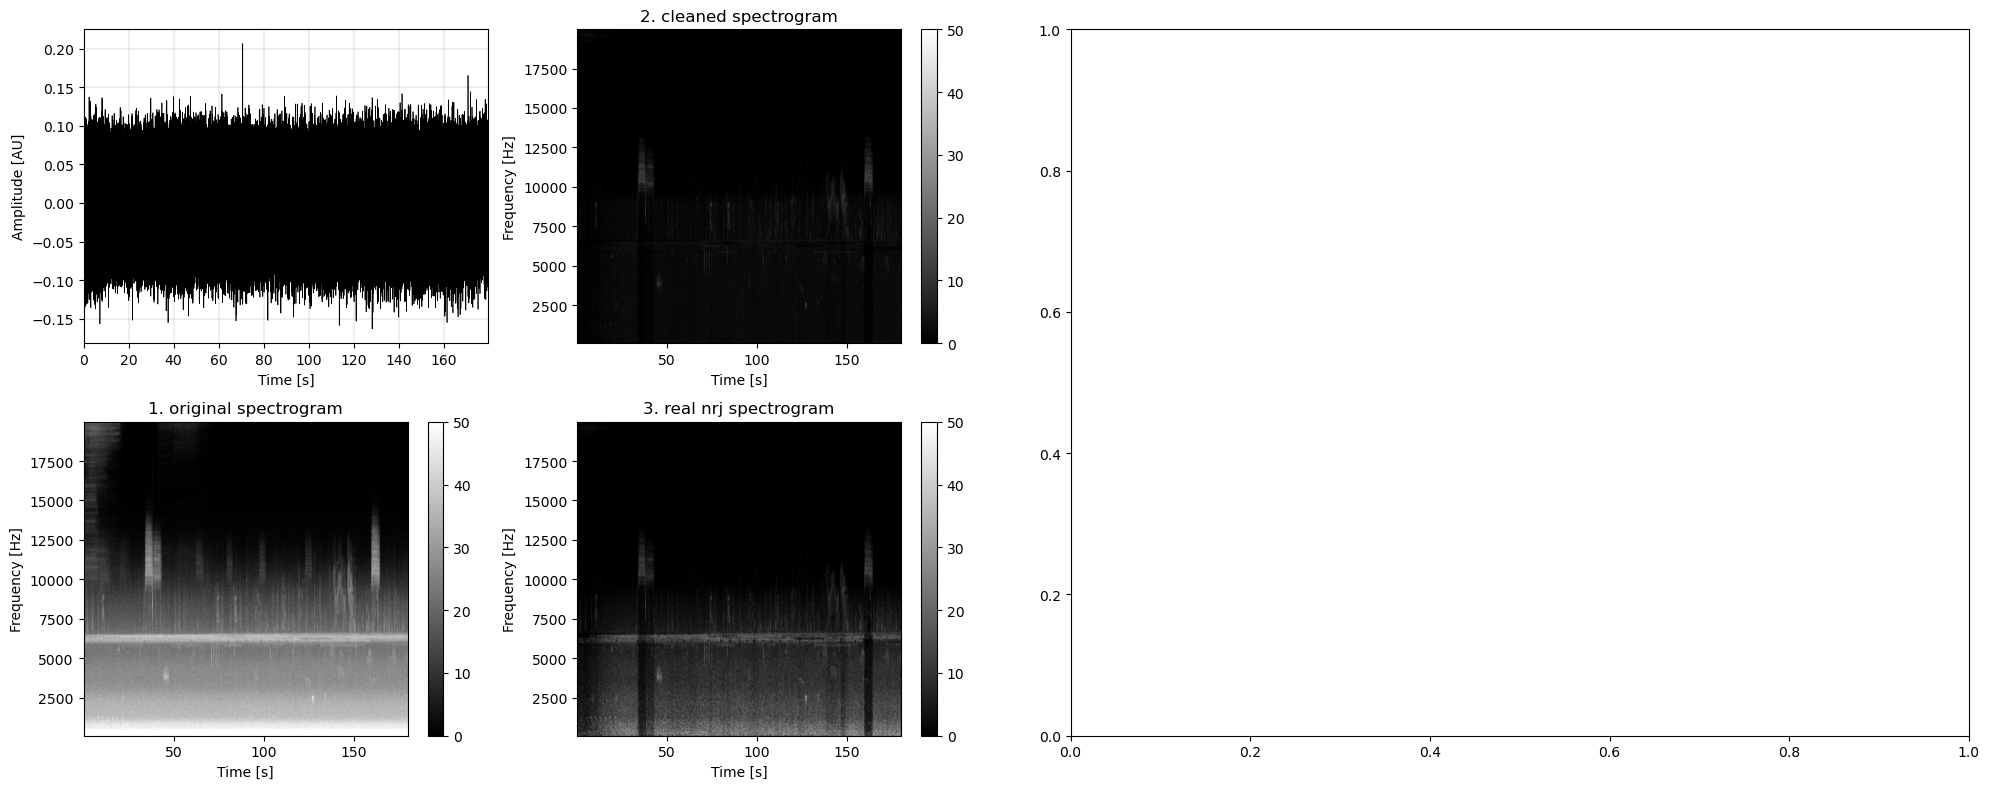

In [46]:
import maad
import matplotlib.pyplot as plt

params_temp = params['PARAMS_EXTRACT']

# 0. Load the audio file
sig = maad.sound.load(df['fullfilename'].iloc[12])[0]

# 1. compute the spectrogram
Sxx, tn, fn, ext = maad.sound.spectrogram(
                            sig,
                            params_temp["SAMPLE_RATE"],
                            nperseg=params_temp["NFFT"],
                            noverlap=params_temp["NFFT"] // 2,
                            flims=[params_temp["LOW_FREQ"], params_temp["HIGH_FREQ"]])

if display:
    # creating grid for subplots
    fig = plt.figure()
    fig.set_figheight(8)
    fig.set_figwidth(20)
    ax0 = plt.subplot2grid(shape=(2, 4), loc=(0, 0), colspan=1)
    ax1 = plt.subplot2grid(shape=(2, 4), loc=(1, 0), colspan=1)
    ax2 = plt.subplot2grid(shape=(2, 4), loc=(0, 1), colspan=1)
    ax3 = plt.subplot2grid(shape=(2, 4), loc=(1, 1), colspan=1)
    ax4 = plt.subplot2grid(shape=(2, 4), loc=(0, 2), rowspan=2, colspan=2)

    maad.util.plot_wave(sig, fs=params_temp["SAMPLE_RATE"], ax=ax0)

    maad.util.plot_spectrogram(
        maad.util.power2dB(Sxx, db_range=96) + 96,
        extent=ext,
        ax=ax1,
        title="1. original spectrogram",
        interpolation=None,
        log_scale=False,
        vmin=0,
        vmax=50,
        now=False)

### 1. convert to dB
Sxx_dB = maad.util.power2dB(Sxx, db_range=96) + 96

### 2. Clean spectrogram : remove background)

if params_temp['REMOVE_RAIN']: 
    # remove single vertical lines
    Sxx_clean_dB, Sxx_bckg_vertical_dB = maad.sound.remove_background_along_axis(Sxx_dB.T,
                                                        mode='mean',
                                                        N=1,
                                                        display=False)
    Sxx_dB = Sxx_clean_dB.T

# remove single horizontal lines
Sxx_clean_dB, S_bckg_horizontal_dB = maad.sound.remove_background_along_axis(Sxx_dB,
                                                mode='median',
                                                N=1,
                                                display=False)



# Set the background to 0
Sxx_clean_dB[Sxx_clean_dB<=0] = 0

maad.util.plot_spectrogram(
        Sxx_clean_dB,
        extent=ext,
        ax=ax2,
        title="2. cleaned spectrogram",
        interpolation=None,
        log_scale=False,
        vmin=0,
        vmax=50,
        now=False)


# 
# Add the signal 1D S_bckg_horizontal_dB to the spectrogram Sxx_clean_dB 2D where the Sxx_clean_dB is not 0
Sxx_clean_dB = (Sxx_clean_dB + np.tile(S_bckg_horizontal_dB, (Sxx_clean_dB.shape[1],1)).T) * (Sxx_clean_dB>0)

maad.util.plot_spectrogram(
        Sxx_clean_dB,
        extent=ext,
        ax=ax3,
        title="3. real nrj spectrogram",
        interpolation=None,
        log_scale=False,
        vmin=0,
        vmax=50,
        now=False)

In [ ]:
import maad
import matplotlib.pyplot as plt

params_temp = params['PARAMS_EXTRACT']

# 0. Load the audio file
sig = maad.sound.load(df['fullfilename'].iloc[0])[0]

# 1. compute the spectrogram
Sxx, tn, fn, ext = maad.sound.spectrogram(
                            sig,
                            params_temp["SAMPLE_RATE"],
                            nperseg=params_temp["NFFT"],
                            noverlap=pparams_temparams["NFFT"] // 2,
                            flims=[params_temp["LOW_FREQ"], params_temp["HIGH_FREQ"]])

if display:
    # creating grid for subplots
    fig = plt.figure()
    fig.set_figheight(5)
    fig.set_figwidth(13)
    ax0 = plt.subplot2grid(shape=(2, 4), loc=(0, 0), colspan=1)
    ax1 = plt.subplot2grid(shape=(2, 4), loc=(1, 0), colspan=1)
    ax2 = plt.subplot2grid(shape=(2, 4), loc=(0, 1), colspan=1)
    ax3 = plt.subplot2grid(shape=(2, 4), loc=(1, 1), colspan=1)
    ax4 = plt.subplot2grid(shape=(2, 4), loc=(0, 2), rowspan=2, colspan=2)

    maad.util.plot_wave(sig, fs=params_temp["SAMPLE_RATE"], ax=ax0)

    maad.util.plot_spectrogram(
        Sxx,
        extent=ext,
        ax=ax1,
        title="1. original spectrogram",
        interpolation=None,
        now=False)
    
### 1. convert to dB
Sxx_dB = maad.util.power2dB(Sxx, db_range=96) + 96

### 2. Clean spectrogram : remove background)

if REMOVE_RAIN: 
    # remove single vertical lines
    Sxx_clean_dB, Sxx_bckg_vertical_dB = maad.sound.remove_background_along_axis(Sxx_dB.T,
                                                        mode='mean',
                                                        N=1,
                                                        display=False)
    Sxx_dB = Sxx_clean_dB.T

# remove single horizontal lines
Sxx_clean_dB, S_bckg_horizontal_dB = maad.sound.remove_background_along_axis(Sxx_dB,
                                                mode='median',
                                                N=1,
                                                display=False)
# Set the background to 0
Sxx_clean_dB[Sxx_clean_dB<=0] = 0







CATEGORIES : Data_soto_mashpi_lodge_17jun-05jul2024
NUMBER OF CHUNKS : 6

time resolution 0.011609977324263039s
frequency resolution 43.06640625s

ERROR : operands could not be broadcast together with shapes (62159,) (214369,) 
No ROI was found
use the function <bambird.extract_rois_in_soundscape> to segment ROIS


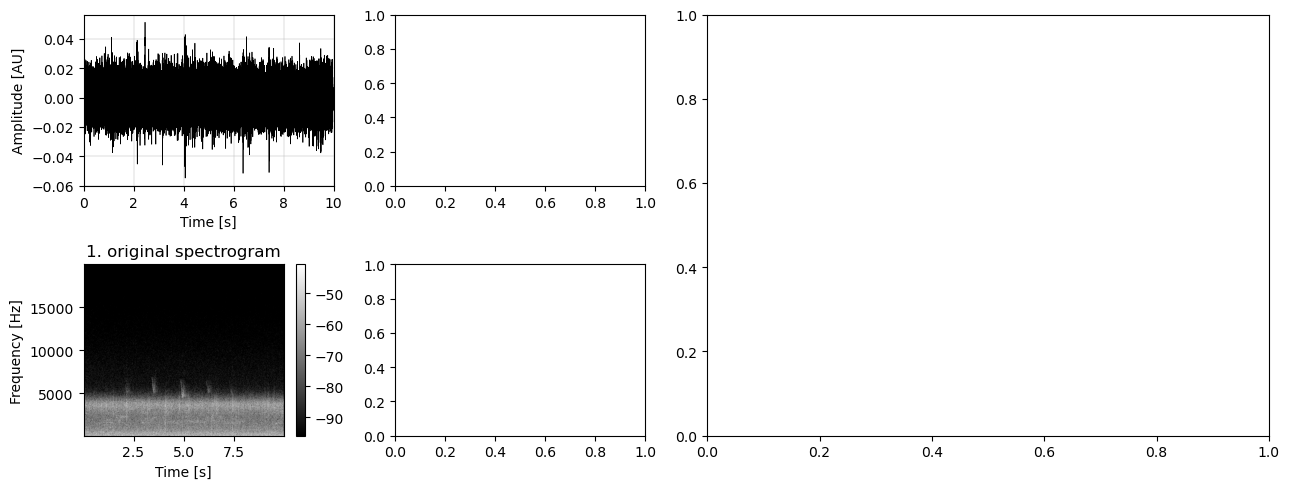

In [7]:
# Extract ROIS of a single file
# -------------------------------

# temporary params to change the total duration of the audio file (otherwise it's too long to process and display)
params_temp = params.copy()
params_temp['PARAMS_EXTRACT']['AUDIO_DURATION'] = 60

# ROIS extraction of a single file
df_rois_single = bambird.single_file_extract_rois (
                    audio_path  = df.sample().fullfilename.squeeze(),
                    # audio_path  = ARCHIVE_PATH / '20240721_015200.wav',  # if a specific file needs to be tested 
                    fun         = params_temp['PARAMS_EXTRACT']['FUNC'],
                    # params      = params['PARAMS_EXTRACT'],
                    params      = params_temp['PARAMS_EXTRACT'],
                    save_path   = DATA_PATH / ROIS_NAME,
                    display     = True,
                    verbose     = True)

# and display the ROIs on the file
# convert the column snr into integer in order to use the value as a label for each ROI
# This is temporary, only on df_rois_single that will not be used after
if len(df_rois_single) > 0 : # test if there is at least a single ROI
  df_rois_single["snr"] = df_rois_single["snr"].apply(int)
  bambird.overlay_rois(
                      cluster         = df_rois_single,
                      params          = params['PARAMS_EXTRACT'],
                      column_labels   = 'snr', 
                      unique_labels   = np.sort(df_rois_single.snr.unique()),
                      filename        = None,
                      random_seed     = None,
                      verbose         = True
                      )
else :
  print("No ROI was found")


# ReLoad the configuration file
# -----------------------------
params = bambird.load_config(PACKAGE_PATH / "src/bambird" / CONFIG_FILE)

### 2.2.2 Extract all the ROIS

It takes about 1 min for 250 1 min audio files

In [10]:
# Extract ROIS
# -------------------------------

# ROIS extraction of the full dataset
df_rois, csv_rois = bambird.multicpu_extract_rois(
                    dataset     = df,
                    params      = params['PARAMS_EXTRACT'],
                    save_path   = DATA_PATH / ROIS_NAME,
                    overwrite   = True,
                    verbose     = True
                    )

print("{} rois were found".format(len(df_rois)))

======================= EXTRACT ROIS =========================

The directory /media/haupert/LaCie/mes_projets_data/erika_ecuador/results/DATASETS_BIRDNET/Enregistrements_Morpho_projet_all_ROIS already exists and will be overwritten
10172 new files will be processed
Composition of the dataset : 
   -number of files : 2265
   -number of categories :  1
   -unique categories : ['default']
<function extract_rois_in_soundscape at 0x7c0907d0c790>


 29%|██▉       | 654/2265 [01:11<02:56,  9.12it/s]


KeyboardInterrupt: 

In [10]:
# find the audio file (filename) in df that are not in the dataframe df_rois
# this is useful to check if some files were not processed
df_missing = df[~df['filename'].isin(df_rois['filename'])]['filename']

print("The number of audio recordings that were not processed is %d / %d" %(len(df_missing), len(df)))
print("List of these audio files :")
display(df_missing)

The number of audio recordings that were not processed is 2265 / 10172
List of these audio files :


32       2MA01537-DSL_20240407_150000.wav
119      2MA01537-DSL_20240501_084800.wav
120      2MA01551-SOT_20240501_084800.wav
132      2MA01551-SOT_20240501_094800.wav
139      2MA01551-SOT_20240501_103300.wav
                       ...               
10051    2MA01557-SOT_20240724_154800.wav
10052    2MA01537-DSL_20240724_154800.wav
10055    2MA01537-DSL_20240724_161800.wav
10161    2MA01537-DSL_20240725_111800.wav
10167    2MA01537-DSL_20240725_120300.wav
Name: filename, Length: 2265, dtype: object

## 2.3 Compute features
It takes about an hour for about 80 000 ROIs

Hide cell ouput (https://pieriantraining.com/jupyter-notebook-output-suppression-a-tutorial/)
1. Select the cell whose output you want to hide.
2. Click on the Cell menu at the top of the screen.
3. Click on Cell Tags.
4. Enter “hide_output” (without quotes) in the input field.
5. Press Enter.

In [6]:
# # Compute features for each ROIS
# # -------------------------------
import time

# test if the csv file DATA_PATH / ROIS_NAME / 'birdnet_features.csv' already exists
if not (DATA_PATH / ROIS_NAME / 'birdnet_features.csv').exists():

    print("Compute the features for each ROI...")

    # compute the features on the full dataset
    # loop over the dataframe df_rois by blocks of 500 rows
    for i in range(0, len(df_rois), 500):
        time.sleep(2)
        clear_output(wait=True)
        try:
            # select the block of 500 rows
            sub_df_rois = df_rois.iloc[i:i+500]
        except:
            # if the last block is smaller than 500
            sub_df_rois = df_rois.iloc[i:]
        # compute the features
        _, _ = bambird.multicpu_compute_features(
                        dataset            = sub_df_rois,
                        params              = params['PARAMS_FEATURES'],
                        save_path           = DATA_PATH / ROIS_NAME,
                        save_csv_filename   ='birdnet_features_'+str(i)+'.csv',
                        overwrite           = True,
                        verbose             = True)

    # merge all the csv files into a single one
    # list all the csv files
    csv_files = glob(str(DATA_PATH / ROIS_NAME / 'birdnet_features_*.csv'))
    # read all the csv files
    df_features = pd.concat([pd.read_csv(file, sep=';') for file in csv_files], ignore_index=True)   
    # save the dataframe into a single csv file
    df_features.to_csv(DATA_PATH / ROIS_NAME / 'birdnet_features.csv', sep=';', index=False)
    # delete the csv files
    for file in csv_files:
        os.remove(file)

else:
    clear_output(wait=True)

    print("The features have already been computed")
    # load the csv file
    df_features = pd.read_csv(DATA_PATH / ROIS_NAME / 'birdnet_features.csv', sep=';')

    print("The number of ROIs is %d" %len(df_features))


The features have already been computed
The number of ROIs is 194629


# Step 3 - Clustering and display




## 3.1 Main clustering

Clustering's steps :

1. Select only ROIs with SNR higher than a threshold (SNR_HLIM). This will help to cluster only the "best" sound events
2. Select ROIs with frequency centroid between low and high limits in order to focus on avian (200Hz-8000Hz), amphibians (0Hz-5000Hz), insects (>4000Hz)...
3. Do the clustering (about 30s)
4. Overlay the clusters
5. Combine ROIs that belong to the same cluster and that are very close to each other in order to form new longer ROIs. This will reduce the number of ROIs to listen to and will help the experts for the identification


In [23]:
# Select ROIS with high SNR
#--------------------------------
df_features_selected = df_features[df_features.snr >= SNR_HLIM]
print("Keep {} ROIs with SNR >= {}dB over {}".format(len(df_features_selected), SNR_HLIM, len(df_features)))

Keep 173390 ROIs with SNR >= 16dB over 194629


In [24]:
# Select ROIS depending on the centroid frequency
#-------------------------------------------------

CENTROID_FREQ_HLIM = 10000
CENTROID_FREQ_LLIM = 100

df_features_selected = df_features_selected[(df_features_selected.centroid_f <= CENTROID_FREQ_HLIM) & (df_features_selected.centroid_f >= CENTROID_FREQ_LLIM)]
print("Keep {} ROIs with centroid frequency between {}Hz and {}Hz".format(len(df_features_selected), CENTROID_FREQ_LLIM, CENTROID_FREQ_HLIM))


Keep 163754 ROIs with centroid frequency between 100Hz and 10000Hz


In [25]:
#  Cluster ROIS
# -------------------------------

# set the params
params_temp = params['PARAMS_CLUSTER'].copy()
params_temp['MIN_PTS'] = 10 
params_temp['MIN_CORE_PTS'] = params_temp['MIN_PTS']

# find the clusters through all the categories
print(df_features_selected['categories'].unique())
# rename the column categories into a single name 'all'
df_features_selected['categories'] = 'all'
print(df_features_selected['categories'].unique())

# find the clusters by categories
df_cluster, csv_cluster = bambird.find_cluster(
                dataset = df_features_selected,
                # params  = params['PARAMS_CLUSTER'],
                params = params_temp,
                display = False,
                verbose = True
                )

['mashpiLodge_canopy_capuch' 'mashpiLodge__mid_capuch'
 'mashpiLodge_soto_capuch' 'mashpi_soto_comuni' 'mashpi_canopy_comuni'
 'mashpi_mid_comuni' 'Data_mid_mashpi_lodge_17jun-05jul2024'
 'Data_canopy_mashpi_lodge_17jun-05jul2024'
 'Data_soto_mashpi_lodge_17jun-05jul2024' 'shungo_canopy' 'shungo_soto']
['all']


====================== CLUSTER FEATURES ======================

______UMAP reduction
EPS is 0.07234159548787121
HDBSCAN eps 0.07234159548787121; min_samples 10; min core samples 10; Number of soundtypes found for all : 903; 44.07159519767456% are clustered


### 3.1.1 Overlay ROIs



============== OVERLAY ROIS ON THE ORIGINAL FILE ==============

Display ROIs found in the file /media/haupert/LaCie/mes_projets_data/erika_ecuador/Enregistrements_Morpho_projet/MASHPI_lodge_capuchTrail/3_week_monit_17jun-05jul/Data_canopy_mashpi_lodge_17jun-05jul2024/2MA01537-DSL_20240619_165700.wav
labels : [ -1  -1 203  91  -1 159 159 159 159 159 159 159 159 339  -1  -1  -1  -1
  -1 159 631 691 866  -1  -1 631  -1 159 171  -1  -1  -1]


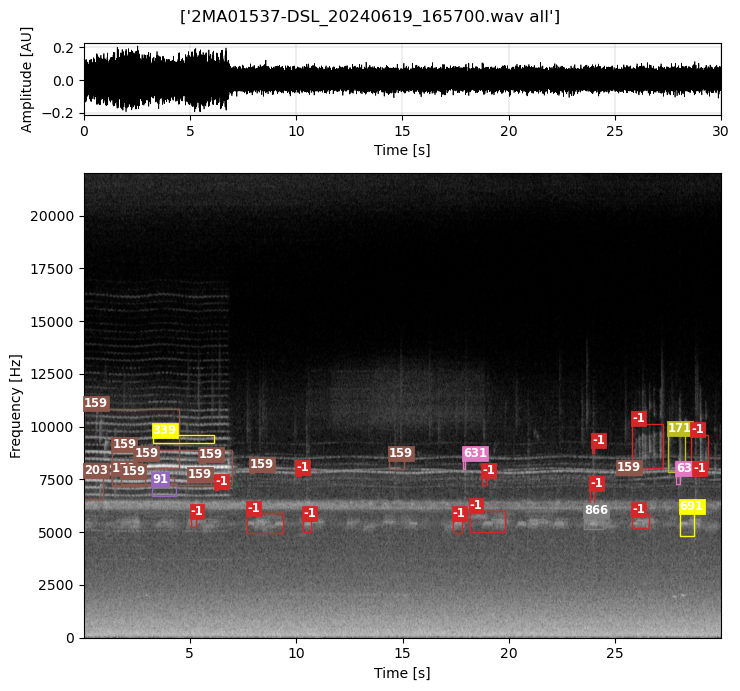

'2MA01537-DSL_20240619_165700.wav'

In [26]:
# Display the ROIS
# -------------------------------

# change the fullfilename path in df_cluster with ARCHIVE_PATH by extracting the filename and adding the path
# df_cluster['fullfilename'] = df_cluster['filename'].apply(lambda x: str(ARCHIVE_PATH / x))
# df_cluster['fullfilename_ts'] = df_cluster['filename_ts'].apply(lambda x: str(ARCHIVE_PATH / x))


bambird.overlay_rois(
                    cluster         = df_cluster,
                    params          = params['PARAMS_EXTRACT'],
                    column_labels   = 'cluster_number', #auto_label cluster_number
                    unique_labels   = np.sort(df_cluster.cluster_number.unique()),
                    # filename        = '20240720_201600.wav', # 20240303_000000 20240302_161000 20240303_014000 20240303_080000 20240302_161000 20240302_214500 20240302_131500 '20240303_023500.WAV', # S4A09128_20211011_033000 S4A09128_20211008_064500 S4A09128_20210211_043000 S4A09128_20211026_044500 S4A09128_20210603_074500 S4A09128_20210917_103000
                    random_seed     = None,
                    verbose         = True
                    )

### 3.1.2 Combination

Combine ROIs from the same cluster that very close to each other 

In [27]:
df_combined = pd.DataFrame()

# loop over the dataframe df_cluster by categories
for CATEGORY in df_cluster['categories'].unique():
    # select the dataframe with the CATEGORY
    sub_df_cluster = df_cluster[df_cluster['categories'] == CATEGORY].copy()

    # combine the ROIs
    df_combined_temp = bambird.multi_cpu_combine_rois(
                                        sub_df_cluster,
                                        remove_noise = True,
                                        params = params['PARAMS_CLUSTER'],
                                        verbose=True)

    # number of rois after combining rois compare to the number of rois before
    print("The number of ROIs before combining ROIs is %d" %len(sub_df_cluster))
    print("The number of ROIs after combining ROIs is %d" %len(df_combined_temp))
    print("The number of ROIs that were combined is %d" %(len(sub_df_cluster) - len(df_combined_temp)))

    # add the dataframe df_combined_temp to the list df_combined
    df_combined = pd.concat([df_combined, df_combined_temp], ignore_index=True, axis=0)




================== COMBINE WAVES FROM SAME CLUSTER =================



100%|██████████| 6645/6645 [29:46<00:00,  3.72it/s]

The number of ROIs before combining ROIs is 163754
The number of ROIs after combining ROIs is 54526
The number of ROIs that were combined is 109228




============== OVERLAY ROIS ON THE ORIGINAL FILE ==============

Display ROIs found in the file /media/haupert/LaCie/mes_projets_data/erika_ecuador/Enregistrements_Morpho_projet/Mashpi_Shungo/shungo_soto/2MA01557-SOT_20240709_065200.wav
labels : [688 688 564 393 525]


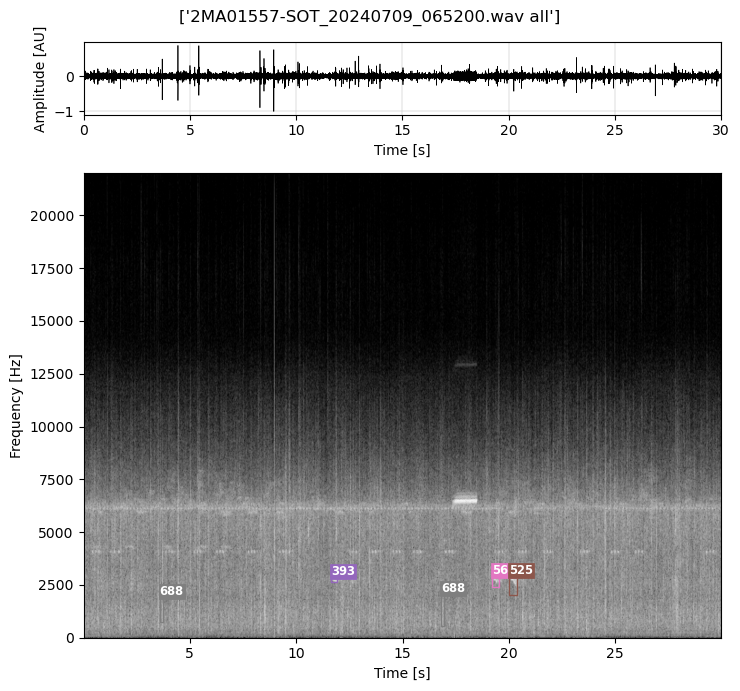

'2MA01557-SOT_20240709_065200.wav'

In [28]:
# Display the ROIS
# -------------------------------

bambird.overlay_rois(
                    cluster         = df_combined,
                    params          = params['PARAMS_EXTRACT'],
                    column_labels   = 'cluster_number', #auto_label cluster_number
                    unique_labels   = np.sort(df_combined.cluster_number.unique()),
                    color_labels    = ['tab:green', 'tab:orange', 'tab:blue', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:olive', 'tab:cyan', 'tab:gray', 'yellow'],
                    filename        = '2MA01557-SOT_20240709_065200.wav', #'20240302_161000.WAV', #  20240302_205000 20240302_214500 20240302_132500 20240302_152500 20240303_075500 '20240303_063500.WAV', #'20240303_023500.WAV', 
                    random_seed     = None,
                    verbose         = True)

## 3.2 Clustering of the noise only

1. Select the ROIs with the cluster number = -1
2. Change/ adapt the clustering parameters to the noise. For instance, the cluster size might be smaller as most of the sounds considered as noise are rare events.
3. Do the clustering (about 10s) and change the cluster number to negative number in order to distinguish the first "big" clusters to the second "smaller" clusters coming from "noise"
4. Overlay the clusters
5. Combine ROIs that belong to the same cluster and that are very close to each other in order to form new longer ROIs. This will reduce the number of ROIs to listen to and will help the experts for the identification


In [29]:
#  Cluster ROIS
# -------------------------------
# get the samples in df_cluster that are noise (cluster_number = -1) and then
# get the samples from index in df_cluster_noise in df_features_selected that are noise (cluster_number = -1)
df_features_noise = df_features_selected.loc[df_cluster[df_cluster.cluster_number == -1].index]

# # set the params
params_temp = params['PARAMS_CLUSTER'].copy()
params_temp['MIN_PTS'] = 10
params_temp['MIN_CORE_PTS'] = params_temp['MIN_PTS'] 

# find the clusters by categories
df_cluster_noise, csv_cluster_noise = bambird.find_cluster(
                dataset = df_features_noise,
                # params  = params['PARAMS_CLUSTER'],
                params = params_temp,
                save_csv_filename = 'cluster_noise.csv',
                display = False,
                verbose = True
                )

# Remove the noise cluster from the df_cluster_noise
# df_cluster_noise = df_cluster_noise.loc[df_cluster_noise[df_cluster_noise.cluster_number != -1].index]

# add +9000 to the cluster number of the noise to avoid confusion with the other clusters
df_cluster_noise['cluster_number'] = df_cluster_noise['cluster_number'].apply(lambda x: x+9000)




====================== CLUSTER FEATURES ======================

______UMAP reduction
EPS is 0.08930976407536859
HDBSCAN eps 0.08930976407536859; min_samples 10; min core samples 10; Number of soundtypes found for all : 571; 34.30911175410821% are clustered


### 3.2.1 Overlay ROIs



============== OVERLAY ROIS ON THE ORIGINAL FILE ==============

Display ROIs found in the file /media/haupert/LaCie/mes_projets_data/erika_ecuador/Enregistrements_Morpho_projet/Mashpi_Shungo/shungo_canopy/2MA01537-DSL_20240718_071300.wav
labels : [8999 9483 8999 8999 8999 8999 8999 8999 9569 9569 8999 9569 8999 8999
 9357 8999 8999 8999 9247 9475 9441 9476 9569 9569 9566 8999 8999 8999
 8999 8999 9371]


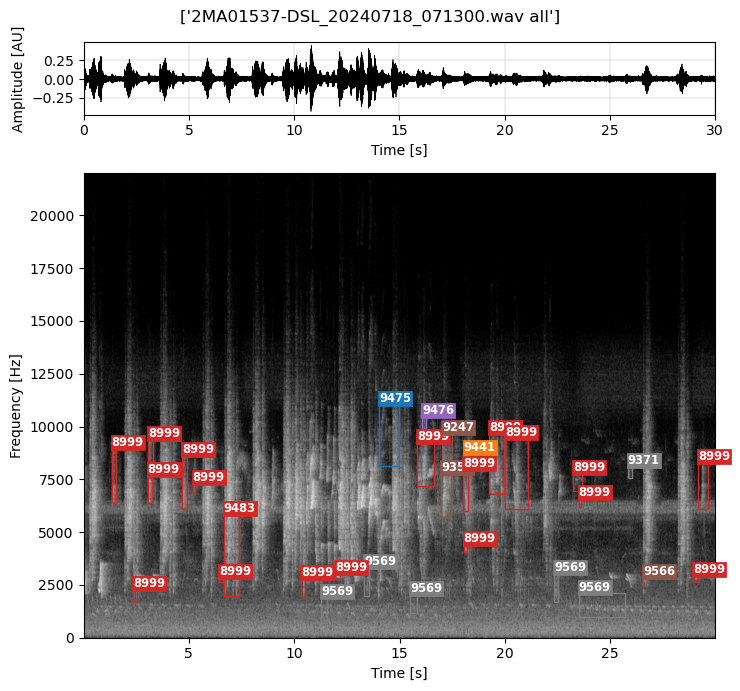

'2MA01537-DSL_20240718_071300.wav'

In [30]:
# Display the ROIS
# -------------------------------
bambird.overlay_rois(
                    cluster         = df_cluster_noise,
                    params          = params['PARAMS_EXTRACT'],
                    column_labels   = 'cluster_number', #auto_label cluster_number
                    unique_labels   = np.sort(df_cluster_noise.cluster_number.unique()),
                    # filename        = '20240303_050000.WAV', # 20240303_074000.WAV 20240302_130000
                    random_seed     = None,
                    verbose         = True
                    )

### 3.2.2 Combination

In [31]:
df_combined_noise = pd.DataFrame()

# loop over the dataframe df_cluster_noise by categories
for CATEGORY in df_cluster_noise['categories'].unique():
    # select the dataframe with the CATEGORY
    sub_df_cluster = df_cluster_noise[df_cluster_noise['categories'] == CATEGORY].copy()

    # combine the ROIs
    df_combined_temp = bambird.multi_cpu_combine_rois(
                                        sub_df_cluster,
                                        remove_noise = True,
                                        params = params['PARAMS_CLUSTER'],
                                        verbose=True)

    # number of rois after combining rois compare to the number of rois before
    print("The number of ROIs before combining ROIs is %d" %len(sub_df_cluster))
    print("The number of ROIs after combining ROIs is %d" %len(df_combined_temp))
    print("The number of ROIs that were combined is %d" %(len(sub_df_cluster) - len(df_combined_temp)))

    # add the dataframe df_combined_temp to the list df_combined_noise
    df_combined_noise = pd.concat([df_combined_noise, df_combined_temp], ignore_index=True, axis=0)




================== COMBINE WAVES FROM SAME CLUSTER =================



100%|██████████| 6675/6675 [35:51<00:00,  3.10it/s]

The number of ROIs before combining ROIs is 91585
The number of ROIs after combining ROIs is 49307
The number of ROIs that were combined is 42278




============== OVERLAY ROIS ON THE ORIGINAL FILE ==============

Display ROIs found in the file /media/haupert/LaCie/mes_projets_data/erika_ecuador/Enregistrements_Morpho_projet/MASHPI_lodge_capuchTrail/3_week_monit_17jun-05jul/Data_canopy_mashpi_lodge_17jun-05jul2024/2MA01537-DSL_20240701_053000.wav
labels : [9286 9286 9286 9286 8999 8999 8999 8999 8999 8999 9402 9287 9279 9290
 9569 9503]


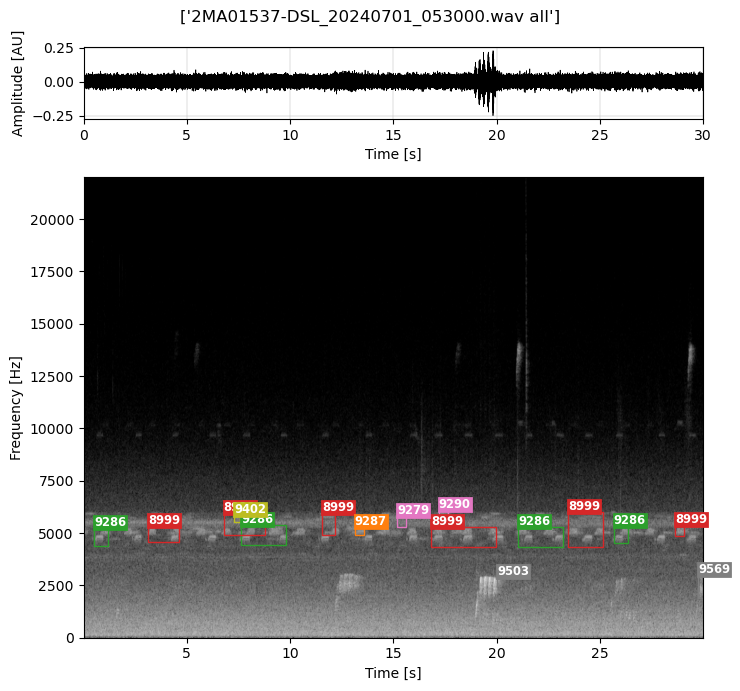

'2MA01537-DSL_20240701_053000.wav'

In [46]:
# Display the ROIS
# -------------------------------

bambird.overlay_rois(
                    cluster         = df_combined_noise,
                    params          = params['PARAMS_EXTRACT'],
                    column_labels   = 'cluster_number', #auto_label cluster_number
                    unique_labels   = np.sort(df_cluster_noise.cluster_number.unique()),
                    # filename        = None,
                    # filename        = '20240302_161000.WAV', # 20240302_161000 20240303_063500 20240303_075500 '20240303_063500.WAV', #'20240303_023500.WAV', # S4A09128_20211011_033000 S4A09128_20211008_064500 S4A09128_20210211_043000 S4A09128_20211026_044500 S4A09128_20210603_074500 S4A09128_20210917_103000
                    random_seed     = None,
                    verbose         = True
                    )

## 3.3 Combine cluster and cluster with noise

### 3.3.1 Combination



============== OVERLAY ROIS ON THE ORIGINAL FILE ==============

Display ROIs found in the file /media/haupert/LaCie/mes_projets_data/erika_ecuador/Enregistrements_Morpho_projet/MASHPI_lodge_capuchTrail/3_week_monit_17jun-05jul/Data_soto_mashpi_lodge_17jun-05jul2024/2MA01557-SOT_20240629_064000.wav
labels : [817 817 765 765 900 271 8999 8999 8999 8999]


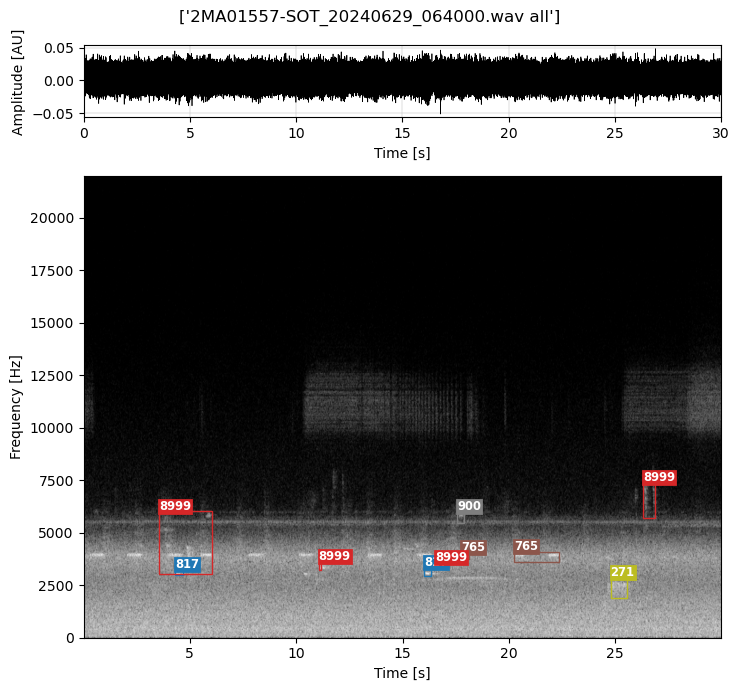

'2MA01557-SOT_20240629_064000.wav'

In [47]:
# merge df_cluster and df_cluster_noise
df_combined_all = pd.concat([df_combined, df_combined_noise], ignore_index=True)

# Display the ROIS
# -------------------------------

bambird.overlay_rois(
                    cluster         = df_combined_all,
                    params          = params['PARAMS_EXTRACT'],
                    column_labels   = 'cluster_number', #auto_label cluster_number
                    unique_labels   = np.sort(df_combined_all.cluster_number.unique()),
                    # filename        = 'S4A09154_20210115_120000.wav', # 20240302_214500 20240302_205000 20240302_161000 20240303_063500 20240303_075500 '20240303_063500.WAV', #'20240303_023500.WAV', 
                    random_seed     = None,
                    verbose         = True
                    )


### 3.3.2 Display the Rois of a single cluster

* Select the cluster number that you want to display
* Loop over the clusters with the selected number to display their spectrogram

The number of ROIs in the cluster 9002 is 15


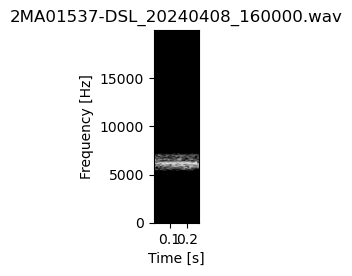

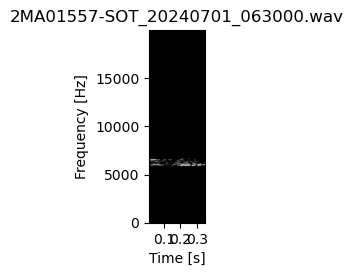

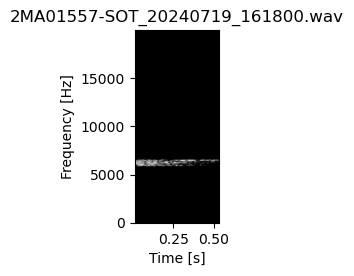

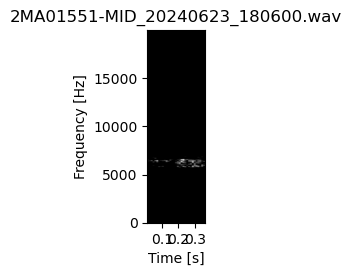

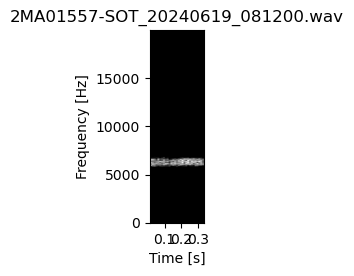

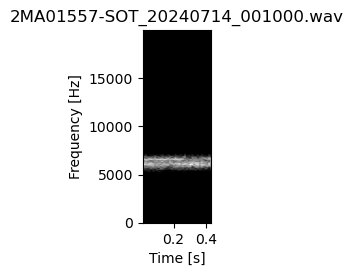

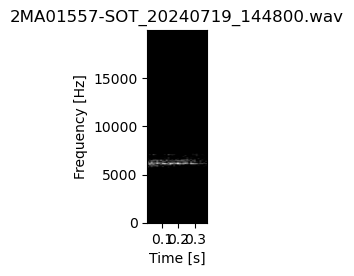

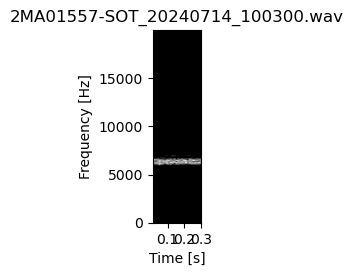

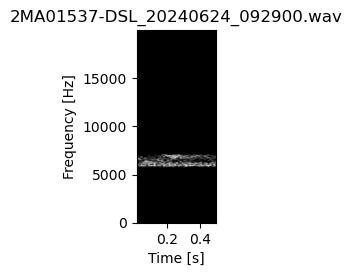

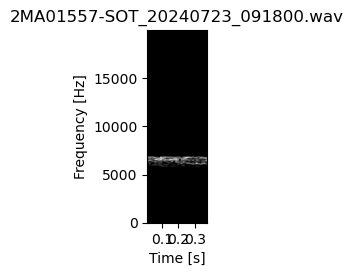

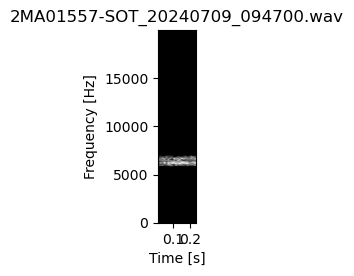

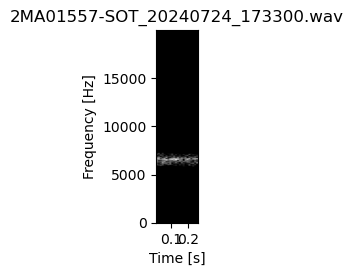

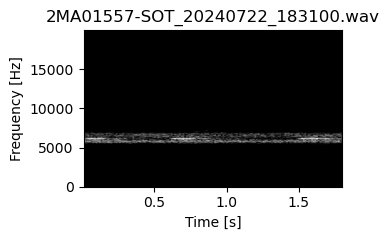

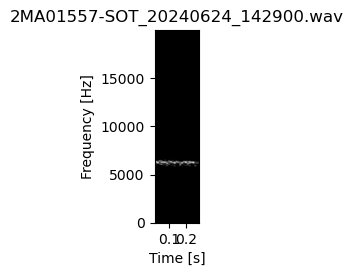

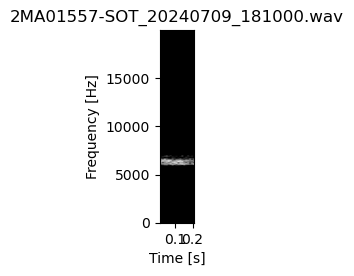

In [68]:
NN = 9002

# print the number of ROIs in the cluster NN
print("The number of ROIs in the cluster %d is %d" %(NN, len(df_combined_all[df_combined_all.cluster_number == NN])))

# select randomly 15 ROIs in the cluster NN
for idx, row in df_combined_all[df_combined_all.cluster_number == NN].sample(min((len(df_combined_all[df_combined_all.cluster_number == NN]), 20))).iterrows():
    # open the audio file
    s, fs = maad.sound.load(row['fullfilename'])
    # trim the audio file
    s = maad.sound.trim(s, fs, row['min_t'], row['max_t'])
    # select the bandwidth
    s = maad.sound.select_bandwidth(s, fs, fcut=[row['min_f'], row['max_f']], forder=3, ftype='bandpass')
    # compute the spectrogram
    Sxx, tn, fn, ext = maad.sound.spectrogram(s, fs, nperseg=1024, noverlap=512, flims=(0,20000))
    # display the spectrogram
    maad.util.plot_spectrogram(Sxx, extent=ext, db_range=80, figsize=(1.5, (len(s)/fs)*2), title=os.path.basename(row['fullfilename']), interpolation=None, colorbar=False)

## 3.4 Prepare clusters

1. Find representative samples and save dataframe
2. add columns and save the results in a csv

In [ ]:
# Reorder the dataframe by cluster_number starting by the biggest size
# --------------------------------------------------------------------

df_cluster_combined = df_combined_all.copy()

# count the number of each cluster_number
counts = df_cluster_combined["cluster_number"].value_counts()

# sort counts value from the highest count to the lowest
counts = counts.sort_values(ascending=False)

# map the count to the cluster_number
df_cluster_combined['count'] = df_cluster_combined['cluster_number'].apply(lambda x: counts.get(x, str(-1)))

# Reorder the dataframe starting the highest number of clusters 
df_cluster_combined.sort_values(by='count', ascending=False, inplace=True)


Compute different metrics (cosine_likeness dist_likeness normdist) to estimate the likeness or the distance to the "centroid" of a cluster (= features of all ROIs that belongs to a cluster are averaged)

In [ ]:

METRIC = 'dist' # normdist cosine dist (cosine_likeness dist_likenes : be carefull in this case the highest the better)

# find representative samples and save dataframe
#------------------------------------------------
df_cluster_repsamples = find_representative_samples(df_cluster_combined)

# select the top 50 samples per cluster
#----------------------------------------
# Group the dataframe by category and get the top 20 rows per category based on lowest normdist. Remove noise cluster (-1)
cols = ['cluster_number', 'count', 'filename_ts',  'fullfilename_ts', 'fullfilename','filename', 'min_t', 'max_t', 'min_f', 'max_f', METRIC, 'model', 'date','label'] 
cols = [x for x in cols if x in df_cluster_repsamples.columns]
df_cluster_selected = df_cluster_repsamples[cols].groupby('cluster_number').apply(lambda x: x.nsmallest(NUM_SAMPLES_BY_CLUSTER, METRIC) if len(x) >= NUM_SAMPLES_BY_CLUSTER else x)
# reset the index
df_cluster_selected.reset_index(drop=True, inplace=True)
# remove the noise cluster
df_cluster_selected = df_cluster_selected.loc[~ (df_cluster_selected.cluster_number==-1),:]

# test if the column date exists    
if 'date' in df_cluster_selected.columns:
    # cast the column date to datetime
    df_cluster_selected['date'] = pd.to_datetime(df_cluster_selected['date'])
    # add a column period with night (from 19h to 6h) dawn (from 6h to 9h) day (from 9h to 16h) and dusk (from 16h to 19h)
    df_cluster_selected['period'] = df_cluster_selected['date'].apply(lambda x: '1. night' if x.hour >= 19 or x.hour < 6 else '2. dawn' if x.hour >= 6 and x.hour < 9 else '3. day' if x.hour >= 9 and x.hour < 16 else '4. dusk')

# test if the column label exists
if 'label' in df_cluster_selected.columns:
    # rename the column label into suggested label
    df_cluster_selected.rename(columns={'label':'suggested_label'}, inplace=True)

# add columns for the group (insect, bird, bat, frog, noise, unknown), scientific_name, english_name, portugese_name
df_cluster_selected['group (insect, bird, bat, frog, noise, unknown)'] = ''
df_cluster_selected['scientific_name'] = ''
df_cluster_selected['english_name'] = ''
df_cluster_selected['portugese_name'] = ''

# reorder the columns
cols = ['cluster_number', 'filename_ts', 'period', 'suggested_label', 'group (insect, bird, bat, frog, noise, unknown)', 'scientific_name', 'english_name', 'portugese_name', 'date', 'fullfilename_ts', 'fullfilename','filename', 'min_t', 'max_t', 'min_f', 'max_f', METRIC]    
cols = [x for x in cols if x in df_cluster_selected.columns]
df_cluster_selected = df_cluster_selected[cols]
# reorder the dataframe by cluster_number and by period 
df_cluster_selected.sort_values(by=['cluster_number', 'date', 'period'], inplace=True)

# save the dataframe
#--------------------
filename = str(DATASET_NAME) + '_CLUSTERS_COMBINED.csv'
# test if the directory exists
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)
df_cluster_selected.to_csv(SAVE_PATH / filename, index=False)

## 3.5 Save the ROIs in the folders corresponding to the cluster number

If a date is provided, the ROIs are saved in one of the 4 subfolder  corresponding to night / daw / day / dusk

In [ ]:
# test the function extract_roi on a row of df_cluster_selected
incr = 0
for idx, row in df_cluster_selected.iterrows():
    # extrac the filename without the extension
    filename_ts = row['filename'].split('.')[0] + '_' + str(incr) + '.WAV'
    df_cluster_selected.loc[idx, 'filename_ts'] = filename_ts

    # test if the column date exists    
    if 'period' in df_cluster_selected.columns: 
        # create the fullfilename_ts path
        fullfilename_ts = str(SAVE_PATH / Path(str(DATASET_NAME) +  ('_CLUSTERS_COMBINED'))  / str(row['cluster_number']) / str(row['period']) / filename_ts)
    else:
        # create the fullfilename_ts path
        fullfilename_ts = str(SAVE_PATH / Path(str(DATASET_NAME) +  ('_CLUSTERS_COMBINED'))  / str(row['cluster_number']) / filename_ts)

    df_cluster_selected.loc[idx, 'fullfilename_ts'] = fullfilename_ts
    roi = extract_roi(
                row['fullfilename'], 
                row['min_t'], row['max_t'], row['min_f'], row['max_f'], 
                margins = [0.25, 250],
                normalize = True,
                save_path=fullfilename_ts)
    incr += 1

# save
filename = str(DATASET_NAME) + '_CLUSTERS_COMBINED.csv'
# test if the directory exists
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)
df_cluster_selected.to_csv(SAVE_PATH / filename, index=False)

Select the metric and then display the most representative ROI of the cluster and then the random ROIs that are below or upper of a threshold

100%|██████████| 24/24 [00:05<00:00,  4.68it/s]


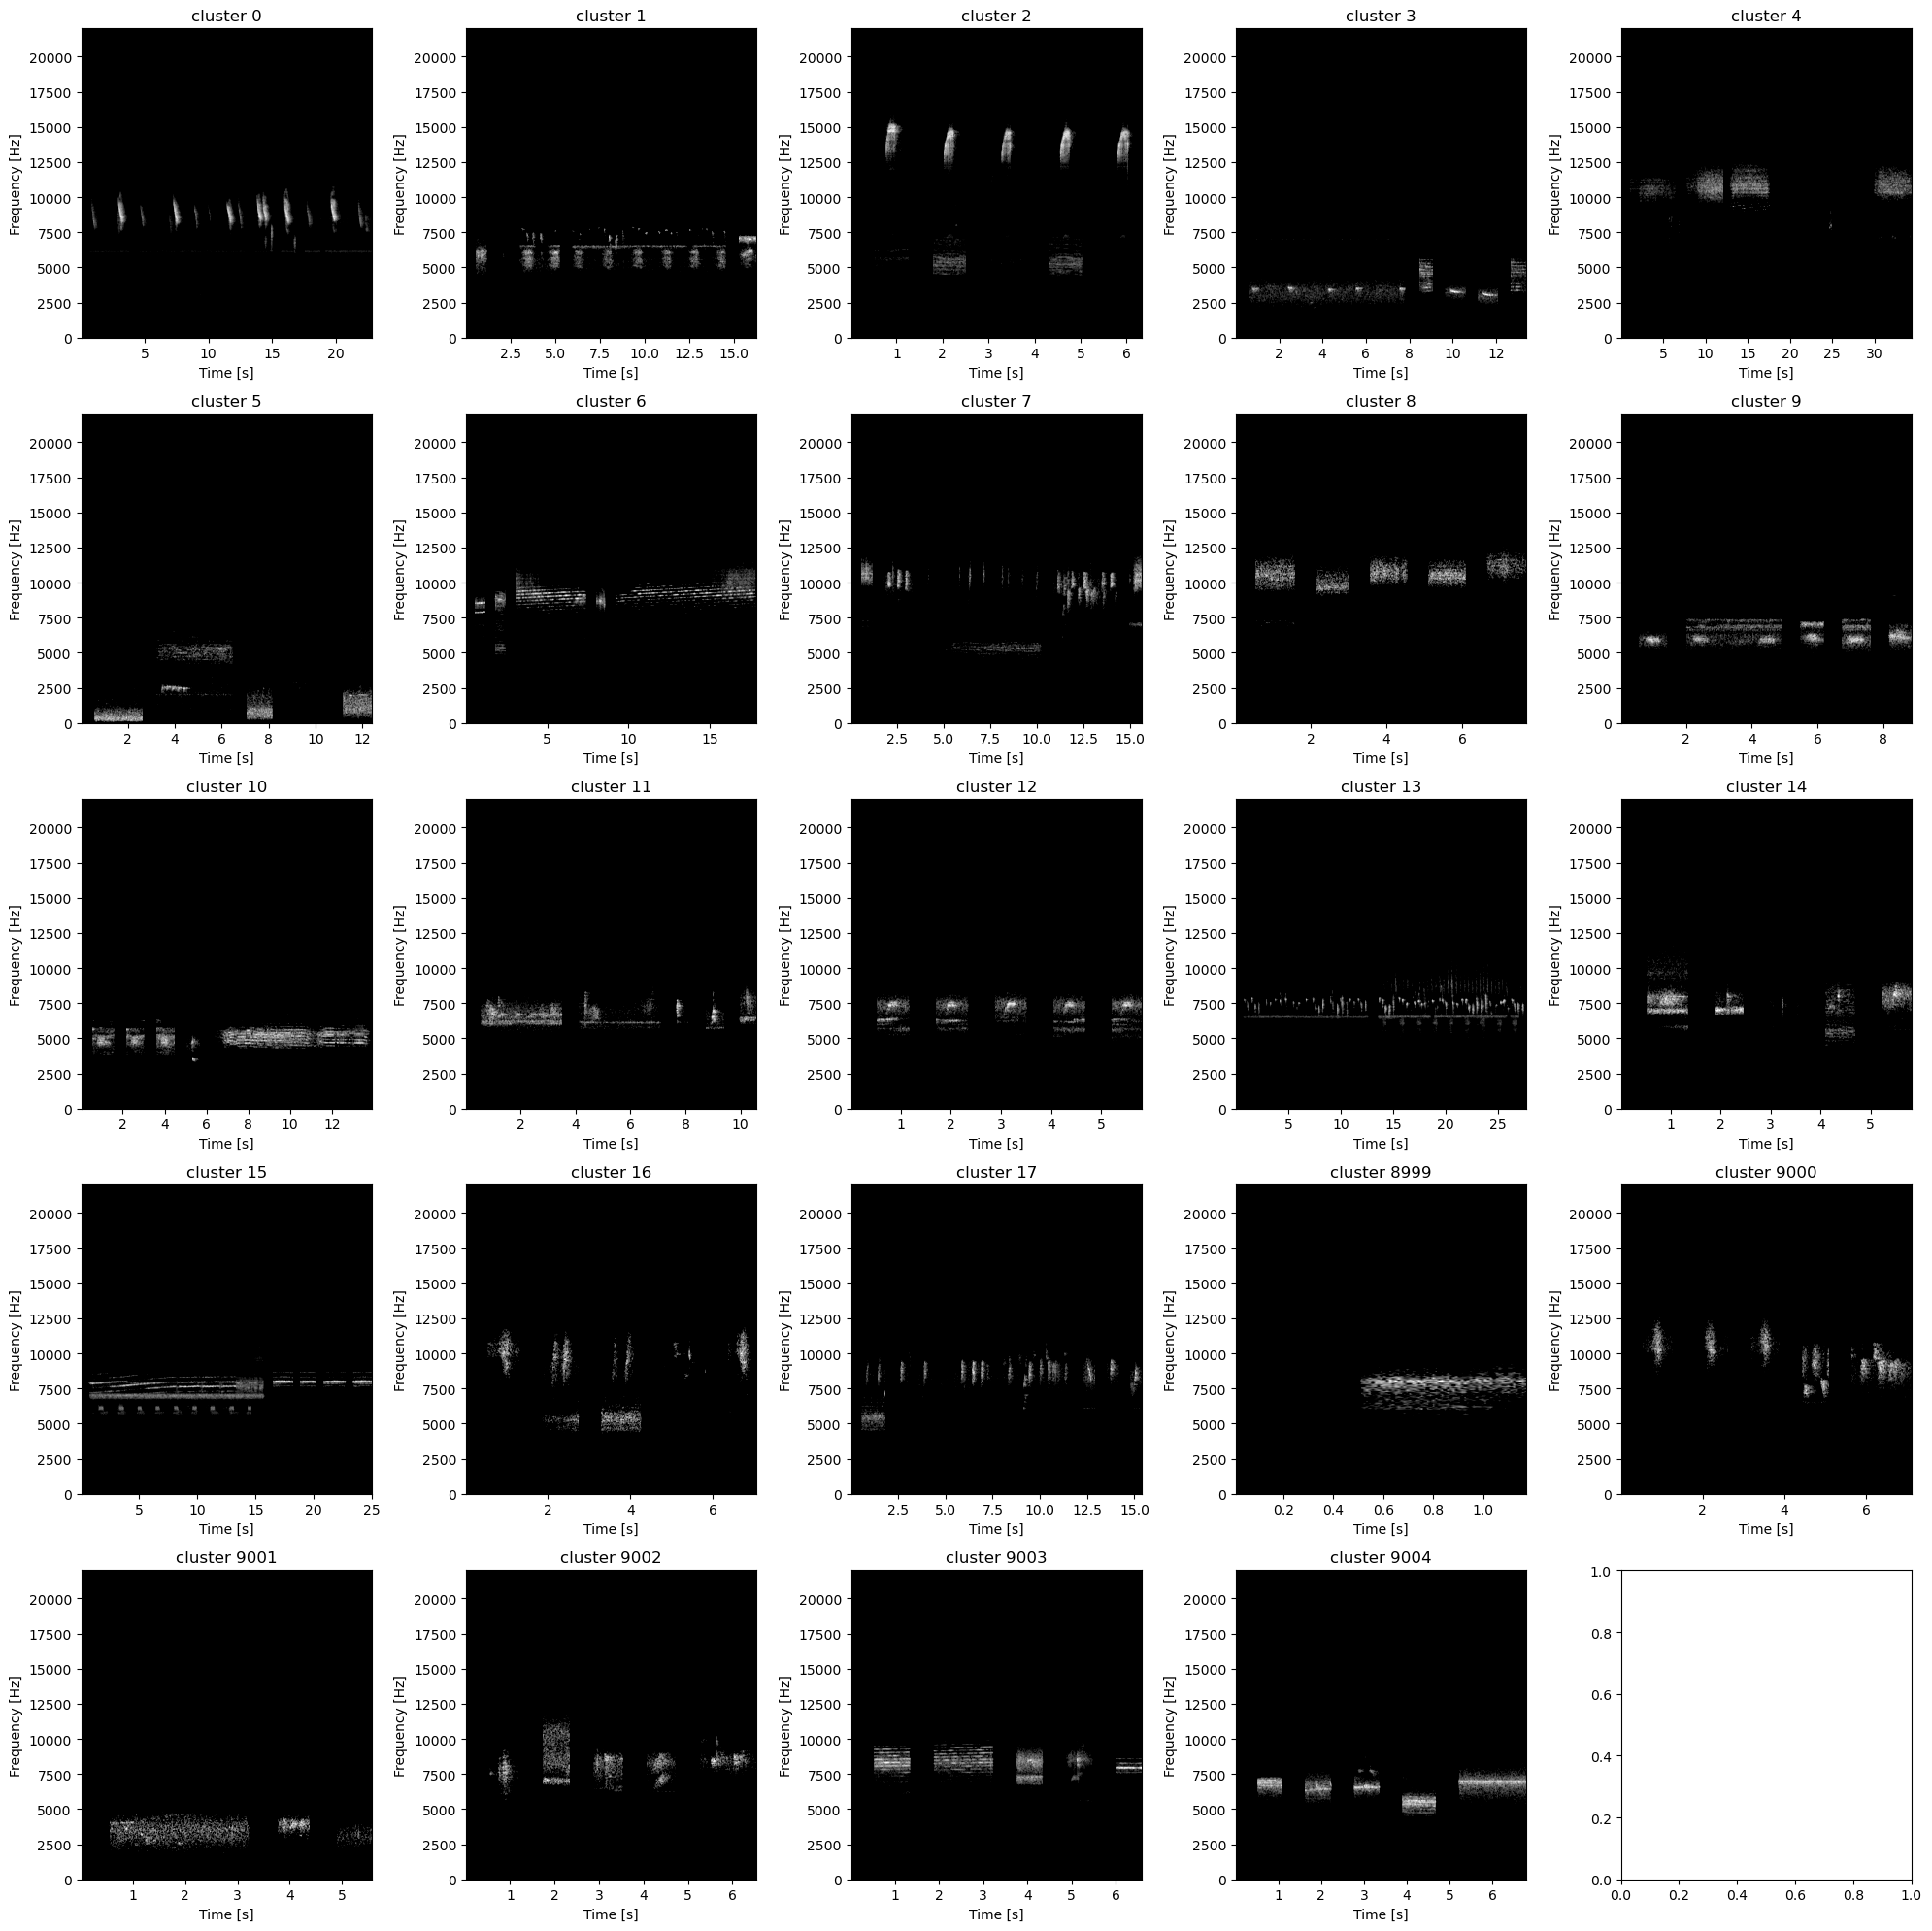

In [ ]:
import matplotlib.pyplot as plt
from math import ceil
from scipy import signal
from tqdm import tqdm

# Create vignettes with the most representative ROIs for each cluster
#----------------------------------------------------------------------

# prepare the grid
columns = 5
rows = ceil(len(df_cluster_selected['cluster_number'].unique()) / columns)
fig, axes = plt.subplots(rows, columns, figsize = (20,20/columns*rows))


# Max number of samples by cluster
NUM_SAMPLES = 5

# initialize the counter
ii = 0

# 1. zero padding
#-----------------------------------------------------------------------
# get the fs
_, fs = maad.sound.load(df_cluster_selected.fullfilename_ts.values[0])

# create the vector of zero padding
duration = 0.5 # in seconds
sig0 = [0] * int(fs*duration)

# 2. load 5 audio for each cluster and concatenate them into a single audio
#-----------------------------------------------------------------------

for num in tqdm(df_cluster_selected['cluster_number'].unique()):

    sub_df = df_cluster_selected[df_cluster_selected['cluster_number'] == num]

    # Sort the dataframe by the value of the metric
    sub_df = sub_df.sort_values(by=METRIC)

    # Sample the rows. Get a maximum of NUM_SAMPLES rows. 
    # Could be less if the dataframe as less rows
    try :
        sub_df = sub_df.iloc[0:NUM_SAMPLES]
    except:
        print("less samples than the number required N={}".format(NUM_SAMPLES))

    # initialize an empty list
    sig = []

    for _ , row in sub_df.iterrows() :

        # load the audio
        sig1, fs = maad.sound.load(row.fullfilename_ts)
        # trim the audio
        # sig1 = maad.sound.trim(sig1, fs, min_t=0, max_t=(len(sig1)/fs)-CNN_MARGINS_T)
        # create a tukey window to avoid discontinuities
        window = signal.windows.tukey(len(sig1), alpha=0.05)
        # apply the window
        sig1 = (sig1 * window).tolist()

        # merge all sig with zero padding in between
        sig  += sig0 + sig1
    
    # list to array
    sig = np.asarray(sig)
    
    # Compute the spectrogram of the concatenate audio
    Sxx, tn, fn, ext = maad.sound.spectrogram(sig, fs, nperseg=1024)

    # Convert into dB from 0dB to 96dB maximum
    Sxx_dB = maad.util.power2dB(Sxx, db_range=96) + 96

    # Plot the spectrogram in the right subplot
    rr = ii // columns
    cc = ii - rr * columns
    maad.util.plot_spectrogram(Sxx_dB, extent=ext, 
                                # db_range=30, 
                                # gain=20, 
                                log_scale = False,
                                now = False,
                                title = 'cluster ' + str(num),
                                colorbar=False, ax=axes[rr, cc],
                                vmin=np.percentile(Sxx_dB,95), vmax=np.percentile(Sxx_dB,99.99))

    ii = ii +1

# 3. Save figure
#-----------------------------------------------------------------------
filename = str(DATASET_NAME) + '.pdf'
plt.savefig(SAVE_PATH /filename)
filename = str(DATASET_NAME) + '.png'
plt.savefig(SAVE_PATH /filename)

# Display
plt.show()